In [19]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("deep_enzymology_motifs.csv")
df.head()


,sequence,meth_A,meth_B,total,label,label_str
0,AAACGAAA,69,54,123,0.0,DNMT3A_preferred
1,AAACGAAC,15,3,18,0.0,DNMT3A_preferred
2,AAACGAAG,79,45,124,0.0,DNMT3A_preferred
3,AAACGAAT,73,79,152,1.0,DNMT3B_preferred
4,AAACGACA,8,3,11,0.0,DNMT3A_preferred


In [20]:
# Mapping of motif positions
pos_map = {
    "-3": 0, "-2": 1, "-1": 2,
    "C": 3, "G": 4,
    "+1": 5, "+2": 6, "+3": 7
}

def position_counts_pref(df, pos, label_str):
    subset = df[df["label_str"] == label_str]["sequence"].tolist()
    counter = Counter(s[pos] for s in subset if isinstance(s, str) and len(s) == 8)
    total = sum(counter.values()) or 1
    return {b: counter.get(b, 0)/total for b in "ACGT"}


In [21]:
stats_pref = {}
for label_str in ["DNMT3A_preferred", "DNMT3B_preferred"]:
    stats_pref[label_str] = {
        p: position_counts_pref(df, idx, label_str)
        for p, idx in pos_map.items()
    }

pref_A_table = pd.DataFrame(stats_pref["DNMT3A_preferred"]).T
pref_B_table = pd.DataFrame(stats_pref["DNMT3B_preferred"]).T

pref_A_table, pref_B_table


(           A         C         G         T
 -3  0.274397  0.137199  0.252583  0.335821
 -2  0.300230  0.121125  0.256602  0.322044
 -1  0.308266  0.042480  0.283582  0.365672
 C   0.000000  1.000000  0.000000  0.000000
 G   0.000000  0.000000  1.000000  0.000000
 +1  0.272675  0.167049  0.236510  0.323766
 +2  0.304822  0.118829  0.300230  0.276119
 +3  0.256602  0.180827  0.282434  0.280138,
            A         C         G         T
 -3  0.247678  0.188854  0.244582  0.318885
 -2  0.315789  0.099071  0.272446  0.312693
 -1  0.297214  0.219814  0.309598  0.173375
 C   0.000000  1.000000  0.000000  0.000000
 G   0.000000  0.000000  1.000000  0.000000
 +1  0.331269  0.027864  0.507740  0.133127
 +2  0.219814  0.061920  0.306502  0.411765
 +3  0.405573  0.021672  0.281734  0.291022)

In [22]:
def position_counts_weighted(df, pos, enzyme):
    if enzyme == "DNMT3A":
        weights = df["meth_A"].values
    elif enzyme == "DNMT3B":
        weights = df["meth_B"].values
    else:
        raise ValueError("enzyme must be DNMT3A or DNMT3B")

    bases = {b: 0.0 for b in "ACGT"}
    total = 0.0

    for seq, w in zip(df["sequence"], weights):
        if not isinstance(seq, str) or len(seq) != 8 or w <= 0:
            continue
        b = seq[pos]
        if b in bases:
            bases[b] += float(w)
            total += float(w)

    total = total or 1.0
    return {b: bases[b] / total for b in "ACGT"}

stats_weighted = {}
for enzyme in ["DNMT3A", "DNMT3B"]:
    stats_weighted[enzyme] = {
        p: position_counts_weighted(df, idx, enzyme)
        for p, idx in pos_map.items()
    }

weighted_A_table = pd.DataFrame(stats_weighted["DNMT3A"]).T
weighted_B_table = pd.DataFrame(stats_weighted["DNMT3B"]).T

weighted_A_table, weighted_B_table


(           A         C         G         T
 -3  0.149934  0.038273  0.115826  0.695966
 -2  0.150001  0.057321  0.107206  0.685472
 -1  0.186468  0.003241  0.119229  0.691062
 C   0.000000  1.000000  0.000000  0.000000
 G   0.000000  0.000000  1.000000  0.000000
 +1  0.317802  0.044591  0.246242  0.391365
 +2  0.282664  0.033958  0.280238  0.403140
 +3  0.329333  0.045371  0.246420  0.378877,
            A         C         G         T
 -3  0.185125  0.018568  0.163638  0.632669
 -2  0.186357  0.017220  0.129078  0.667345
 -1  0.280679  0.005025  0.158715  0.555580
 C   0.000000  1.000000  0.000000  0.000000
 G   0.000000  0.000000  1.000000  0.000000
 +1  0.493791  0.009609  0.297485  0.199114
 +2  0.176436  0.013082  0.432198  0.378284
 +3  0.480756  0.019470  0.183893  0.315881)

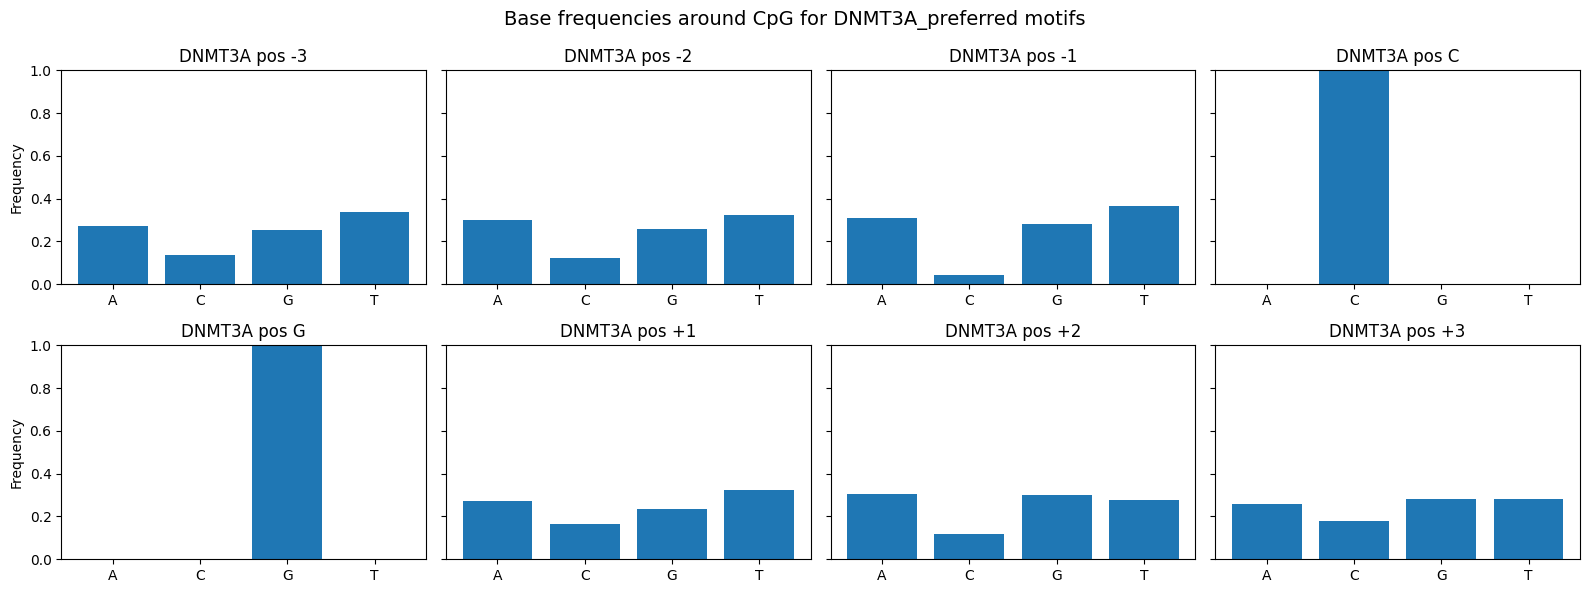

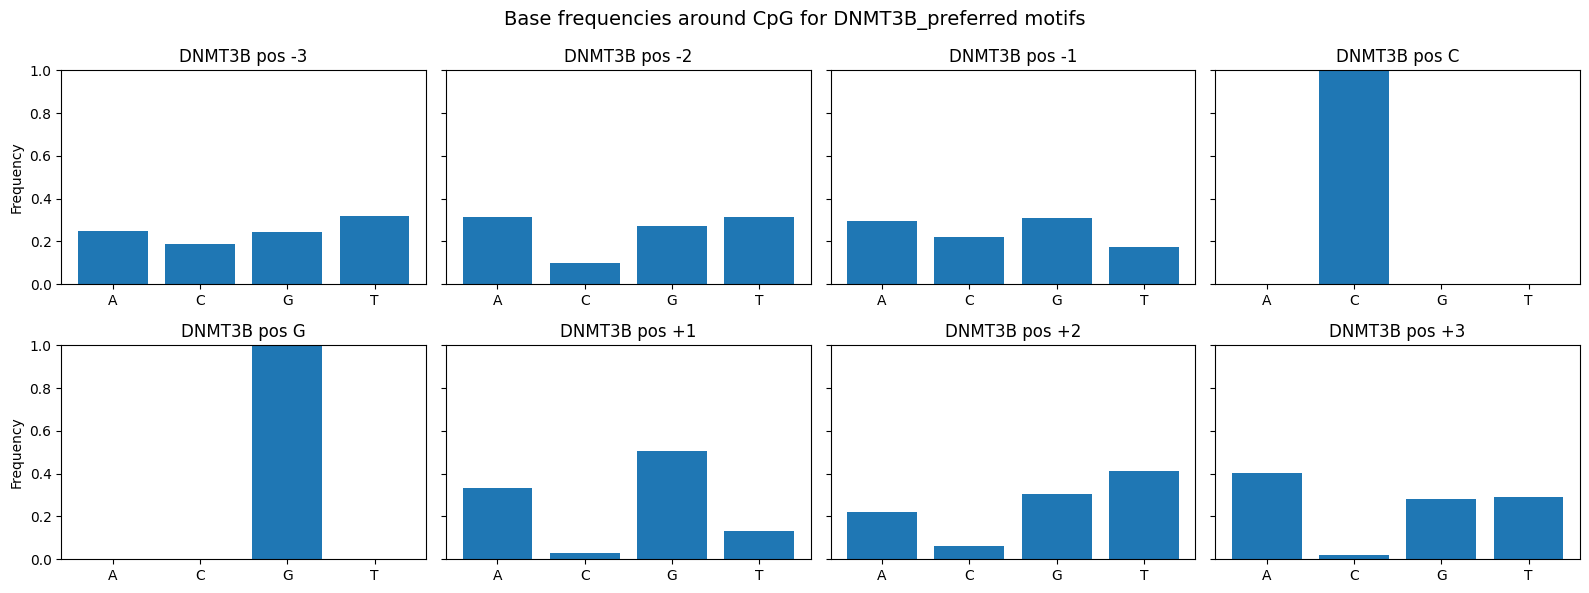

In [23]:
def plot_base_freq_bars(freq_table, title_prefix):
    """
    freq_table: DataFrame with index = positions (-3..+3), columns = A,C,G,T
    title_prefix: string like "DNMT3A" or "DNMT3B"
    """
    positions = list(freq_table.index)
    bases = ["A", "C", "G", "T"]

    fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
    axes = axes.flatten()

    for i, pos in enumerate(positions):
        ax = axes[i]
        vals = [freq_table.loc[pos, b] for b in bases]
        ax.bar(bases, vals)
        ax.set_title(f"{title_prefix} pos {pos}")
        ax.set_ylim(0, 1.0)
        if i % 4 == 0:
            ax.set_ylabel("Frequency")

    fig.suptitle(f"Base frequencies around CpG for {title_prefix}_preferred motifs", fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot for DNMT3A_preferred
plot_base_freq_bars(pref_A_table, "DNMT3A")

# Plot for DNMT3B_preferred
plot_base_freq_bars(pref_B_table, "DNMT3B")


In [28]:
from enzyme_predictor import train_model

model, history = train_model(
    train_csv="deep_enzymology_train.csv",
    val_csv="deep_enzymology_val.csv",
    test_csv="deep_enzymology_test.csv",
    epochs=10,
    batch_size=64,
    lr=1e-3,
    device="cpu"
)

Epoch 01 | train_loss=0.6621 | val_loss=0.5967 | val_acc=0.845 | val_auc=0.461 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 02 | train_loss=0.5475 | val_loss=0.4927 | val_acc=0.845 | val_auc=0.582 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 03 | train_loss=0.4579 | val_loss=0.4297 | val_acc=0.845 | val_auc=0.679 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 04 | train_loss=0.4284 | val_loss=0.4225 | val_acc=0.845 | val_auc=0.758 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 05 | train_loss=0.4233 | val_loss=0.4186 | val_acc=0.845 | val_auc=0.779 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 06 | train_loss=0.4185 | val_loss=0.4153 | val_acc=0.845 | val_auc=0.771 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 07 | train_loss=0.4142 | val_loss=0.4126 | val_acc=0.845 | val_auc=0.758 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 08 | train_loss=0.4106 | val_loss=0.4099 | val_acc=0.845 | val_auc=0.755 | CM={'TP': 0, 'FP': 0, 'FN': 32, 'TN': 174}
Epoch 09

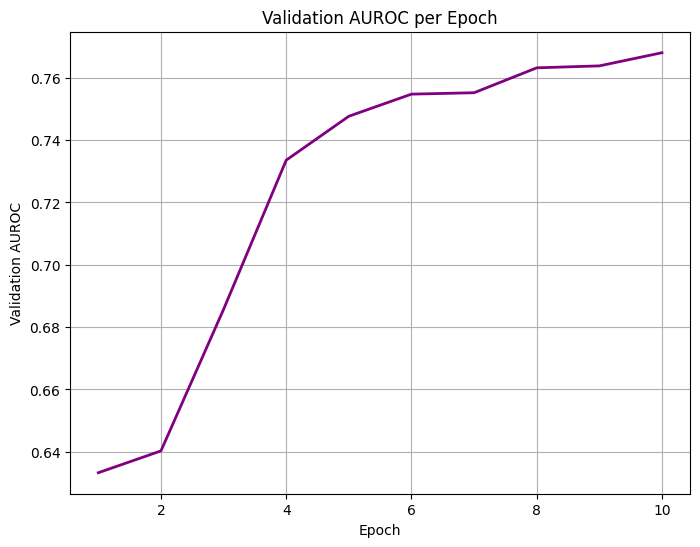

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(history["epoch"], history["val_auc"], color="purple", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation AUROC")
plt.title("Validation AUROC per Epoch")
plt.grid(True)
plt.show()


In [26]:
import matplotlib.pyplot as plt

epochs = history["epoch"]
val_f1  = history["val_f1"]   # make sure this key exists in your history

plt.figure(figsize=(8,6))
plt.plot(epochs, val_f1, linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation F1-score", fontsize=12)
plt.title("Validation F1-score per Epoch", fontsize=14)
plt.grid(True)

plt.show()


KeyError: 'val_f1'